## Задача классификации

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from sklearn.metrics import precision_score

Данные для классификации могут быть даны также в виде таблицы. В отличие от регрессии таргет теперь может принимать только конечное число значений.

In [12]:
data = pd.read_csv("weather_forecast_data.csv")
data.head()

,Temperature,Humidity,Wind_Speed,Cloud_Cover,Pressure,Rain
0,23.720338,89.592641,7.335604,50.501694,1032.378759,rain
1,27.879734,46.489704,5.952484,4.990053,992.614190,no rain
2,25.069084,83.072843,1.371992,14.855784,1007.231620,no rain
3,23.622080,74.367758,7.050551,67.255282,982.632013,rain
4,20.591370,96.858822,4.643921,47.676444,980.825142,no rain


Выделим таргет в отдельный столбец, преобразуем его в True/False и уберём таргет из фичей.

In [13]:
target = data["Rain"] == "rain"
data = data.drop(columns=["Rain"])
data.columns

Index(['Temperature', 'Humidity', 'Wind_Speed', 'Cloud_Cover', 'Pressure'], dtype='str')

Полезно обратить внимание на распределение таргета в наших данных.

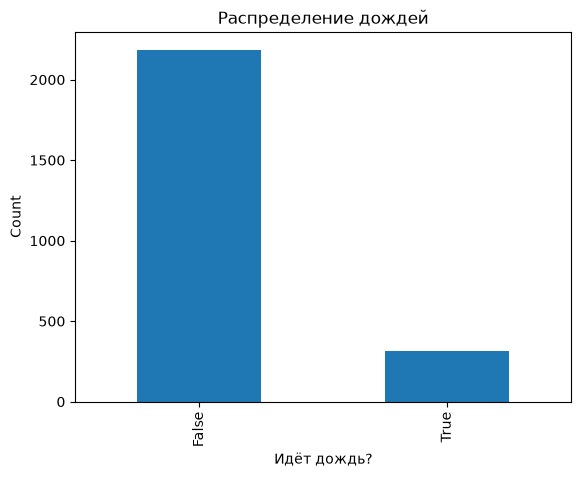

Доля дождей в данных: 0.1256


In [14]:
target.value_counts().sort_index().plot(kind="bar")
plt.xlabel("Идёт дождь?")
plt.ylabel("Count")
plt.title("Распределение дождей")
plt.show()

print(f"Доля дождей в данных: {target.mean()}")

Мы видим, что классы сильно не сбалансированы. Нужно аккуратно поделить на train и val - стратификация.

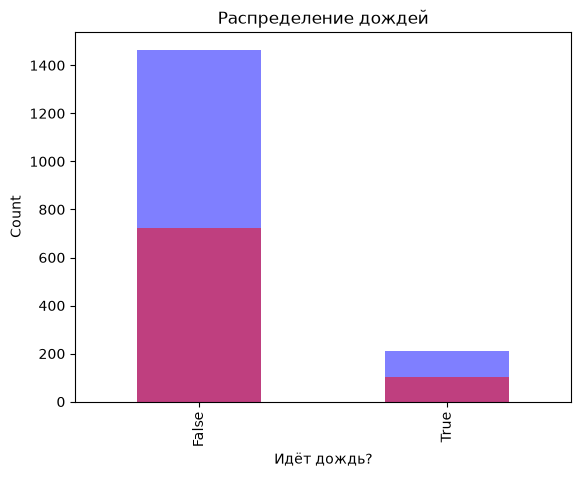

Доля дней без дождей в train данных: 0.8746268656716418
Доля дней без дождей в val данных: 0.8739393939393939
Размер train данных: (1675, 5)
Размер val данных: (825, 5)


In [15]:
train_data, val_data, train_target, val_target = train_test_split(data, target, test_size=0.33, stratify=target, random_state=42)

train_target.value_counts().sort_index().plot(kind="bar", color="blue", alpha=0.5)
val_target.value_counts().sort_index().plot(kind="bar", color="red", alpha=0.5)
plt.xlabel("Идёт дождь?")
plt.ylabel("Count")
plt.title("Распределение дождей")
plt.show()

print(f"Доля дней без дождей в train данных: {1 - train_target.mean()}")
print(f"Доля дней без дождей в val данных: {1 - val_target.mean()}")

print(f"Размер train данных: {train_data.shape}")
print(f"Размер val данных: {val_data.shape}")

### KNN классификатор

In [16]:
from sklearn.neighbors import KNeighborsClassifier

clf = KNeighborsClassifier(n_neighbors=1)
clf.fit(train_data, train_target)
predictions = clf.predict(val_data)

print(f"Количество совпадений: {(predictions == val_target).sum()}")
print(f"Доля совпадений (accuracy): {(predictions == val_target).mean()}")

Количество совпадений: 789
Доля совпадений (accuracy): 0.9563636363636364


[[702  19]
 [ 17  87]]


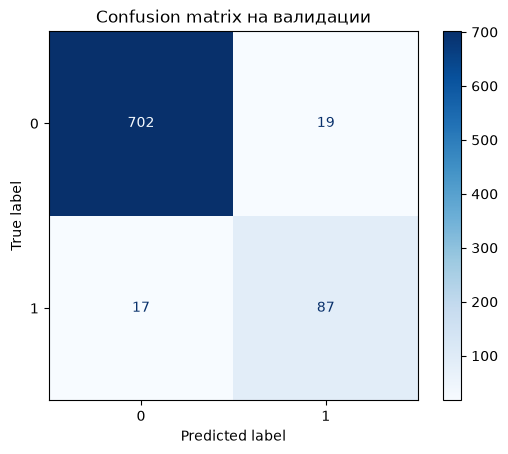

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(val_target, predictions)
print(cm)

ConfusionMatrixDisplay(confusion_matrix=cm).plot(cmap="Blues")
plt.title("Confusion matrix на валидации")
plt.show()

Как видим, мы достаточно хорошо предсказываем погоду, так? Давайте посмотрим, насколько часто мы будем промокать под дождём:

In [18]:
got_wet = cm[1, 0]
brought_umbrella = cm[1, 1]
print(got_wet, brought_umbrella)

recall = brought_umbrella / (got_wet + brought_umbrella)
print(f"Recall: {recall}")
print(f"Доля случаев, когда мы промокнем: {1 - recall}")

17 87
Recall: 0.8365384615384616
Доля случаев, когда мы промокнем: 0.16346153846153844


Мы промокаем достаточно часто. Можно ли сделать лучше?

In [ ]:
# Подберите количество соседей, чтобы промокать поменьше
clf = KNeighborsClassifier(n_neighbors=...)
clf.fit(train_data, train_target)
predictions = clf.predict(val_data)

print(f"Количество совпадений: {(predictions == val_target).sum()}")
print(f"Доля совпадений (accuracy): {(predictions == val_target).mean()}")

print(f"Recall: {recall_score(val_target, predictions)}")

Количество совпадений: 796
Доля совпадений (accuracy): 0.9648484848484848
Recall: 0.8846153846153846


In [20]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(train_data, train_target)
predictions = clf.predict(val_data)

print(f"Количество совпадений: {(predictions == val_target).sum()}")
print(f"Доля совпадений (accuracy): {(predictions == val_target).mean()}")

print(f"Recall: {recall_score(val_target, predictions)}")

Количество совпадений: 758
Доля совпадений (accuracy): 0.9187878787878788
Recall: 0.6057692307692307


### Логистическая регрессия

In [21]:
# Сгенерируем массив точек из двух классов (2 гауссианы)
import numpy as np

np.random.seed(42)
n_samples = 100

class_0 = np.random.multivariate_normal([0, 0], [[2, 0], [0, 2]], n_samples)
class_1 = np.random.multivariate_normal([3, 2], [[2, 0], [0, 2]], n_samples)

data = np.vstack([class_0, class_1])
labels = np.array([0]*n_samples + [1]*n_samples)

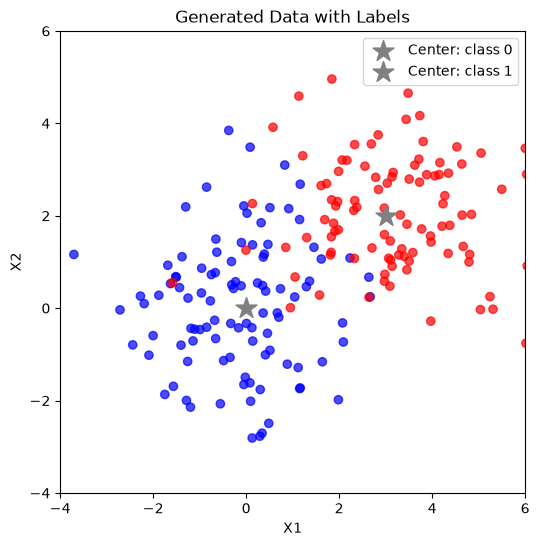

In [22]:
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='bwr', alpha=0.7)
# Draw centers as gray stars
plt.scatter(0, 0, marker='*', color='gray', s=250, label='Center: class 0')
plt.scatter(3, 2, marker='*', color='gray', s=250, label='Center: class 1')
plt.xlim(-4, 6)
plt.ylim(-4, 6)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Generated Data with Labels')
plt.legend()
plt.show()

In [23]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression()
clf.fit(data, labels)

coef = clf.coef_
intercept = clf.intercept_
print(coef, intercept)

[[1.5936699  0.92024017]] [-3.40041347]


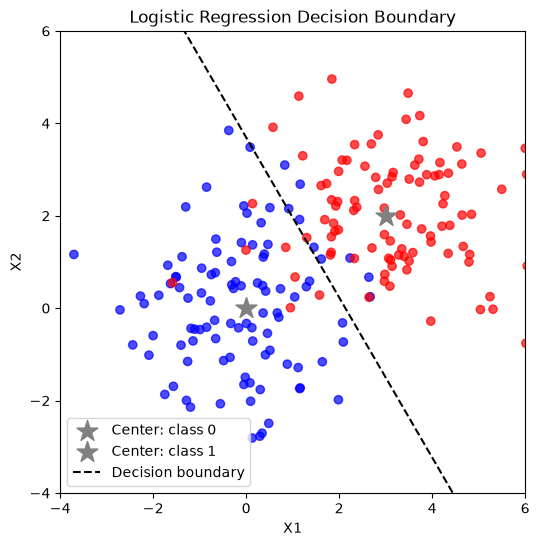

In [24]:
plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='bwr', alpha=0.7)
plt.scatter(0, 0, marker='*', color='gray', s=250, label='Center: class 0')
plt.scatter(3, 2, marker='*', color='gray', s=250, label='Center: class 1')

x1_vals = np.linspace(data[:,0].min() - 1, data[:,0].max() + 1, 100)
a = coef[0,0]
b = coef[0,1]
c = intercept[0]
# Avoid division by zero
if b != 0:
    x2_vals = -(a * x1_vals + c) / b
    plt.plot(x1_vals, x2_vals, 'k--', label='Decision boundary')
else:
    # Vertical line if b == 0
    plt.axvline(-c/a, color='k', linestyle='--', label='Decision boundary')

plt.xlim(-4, 6)
plt.ylim(-4, 6)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

Но не всегда может получаться так красиво.

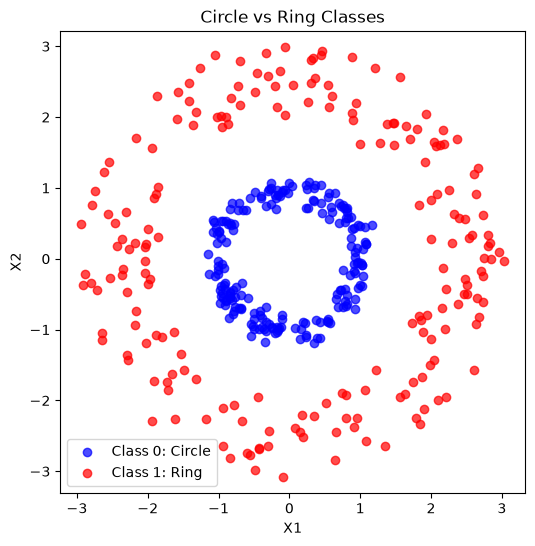

In [25]:
np.random.seed(0)

# Class 0: Points uniformly on a small circle
num_points = 200
r_inner = 1.0
theta_inner = np.random.uniform(0, 2*np.pi, num_points)
x_inner = r_inner * np.cos(theta_inner) + np.random.normal(0, 0.1, num_points)
y_inner = r_inner * np.sin(theta_inner) + np.random.normal(0, 0.1, num_points)
class0 = np.stack([x_inner, y_inner], axis=1)

# Class 1: Points uniformly in a ring (between r=2.0 and r=3.0)
r_outer = np.random.uniform(2.0, 3.0, num_points)
theta_outer = np.random.uniform(0, 2*np.pi, num_points)
x_outer = r_outer * np.cos(theta_outer) + np.random.normal(0, 0.1, num_points)
y_outer = r_outer * np.sin(theta_outer) + np.random.normal(0, 0.1, num_points)
class1 = np.stack([x_outer, y_outer], axis=1)

# Create data and labels
data = np.vstack([class0, class1])
labels = np.array([0]*num_points + [1]*num_points)

# Visualize the generated data
plt.figure(figsize=(6,6))
plt.scatter(class0[:,0], class0[:,1], c='blue', label='Class 0: Circle', alpha=0.7)
plt.scatter(class1[:,0], class1[:,1], c='red', label='Class 1: Ring', alpha=0.7)
plt.xlabel('X1')
plt.ylabel('X2')
plt.legend()
plt.title('Circle vs Ring Classes')
plt.axis('equal')
plt.show()

Понятно, что такие классы прямая разделит плохо.

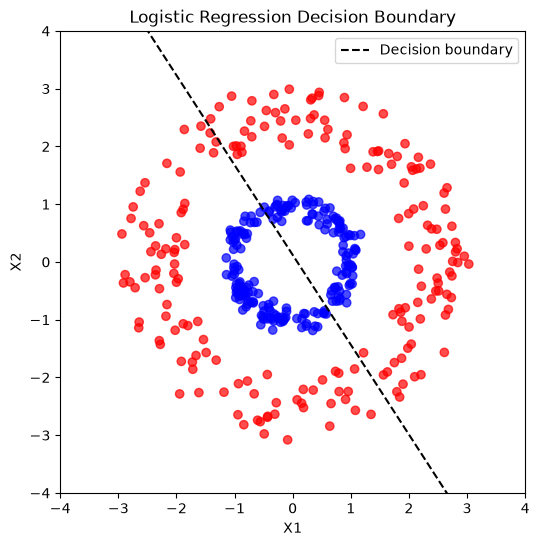

In [26]:
clf = LogisticRegression()
clf.fit(data, labels)

coef = clf.coef_
intercept = clf.intercept_

plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='bwr', alpha=0.7)

x1_vals = np.linspace(data[:,0].min() - 1, data[:,0].max() + 1, 100)
a = coef[0,0]
b = coef[0,1]
c = intercept[0]
# Avoid division by zero
if b != 0:
    x2_vals = -(a * x1_vals + c) / b
    plt.plot(x1_vals, x2_vals, 'k--', label='Decision boundary')
else:
    # Vertical line if b == 0
    plt.axvline(-c/a, color='k', linestyle='--', label='Decision boundary')

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

Добавим фичи, чтобы логистическая регрессия лучше смогла разделить классы.

C:\Users\serza\AppData\Local\Temp\ipykernel_21160\3763766340.py:26: UserWarning: Legend does not support handles for QuadContourSet instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\serza\AppData\Local\Temp\ipykernel_21160\3763766340.py:26: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


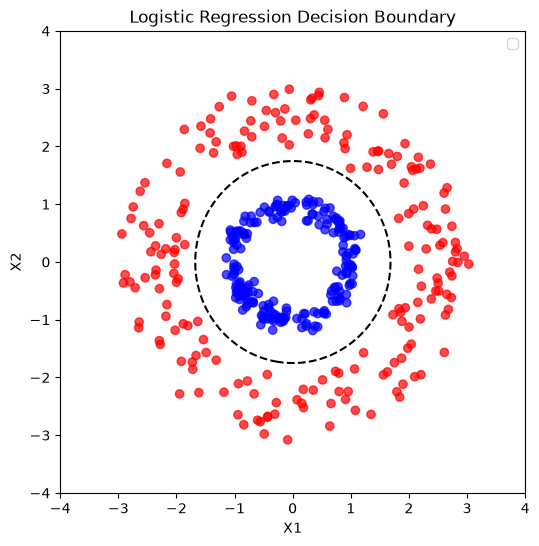

In [27]:
squares = data**2
data = np.hstack([data, squares])
clf = LogisticRegression()
clf.fit(data, labels)

coef = clf.coef_
intercept = clf.intercept_

plt.figure(figsize=(6, 6))
plt.scatter(data[:, 0], data[:, 1], c=labels, cmap='bwr', alpha=0.7)

# Нарисуем границу для логистической регрессии с признаками и их квадратами
x1_grid = np.linspace(data[:, 0].min() - 1, data[:, 0].max() + 1, 200)
x2_grid = np.linspace(data[:, 1].min() - 1, data[:, 1].max() + 1, 200)
xx1, xx2 = np.meshgrid(x1_grid, x2_grid)
# В логистической регрессии сейчас 4 признака: x1, x2, x1^2, x2^2
X_plot = np.c_[xx1.ravel(), xx2.ravel(), xx1.ravel()**2, xx2.ravel()**2]
Z = clf.decision_function(X_plot).reshape(xx1.shape)
plt.contour(xx1, xx2, Z, levels=[0], colors='k', linestyles='--', label='Decision boundary')

plt.xlim(-4, 4)
plt.ylim(-4, 4)
plt.xlabel('X1')
plt.ylabel('X2')
plt.title('Logistic Regression Decision Boundary')
plt.legend()
plt.show()

### Препроцессинг данных
Давайте определять, какие грибы съедобные, а какие - нет.

In [60]:
data = pd.read_csv("mushrooms.csv")
data

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


In [61]:
# e - edible, p - poisonous
target = data["class"] == "e"
data = data.drop(columns=["class"])

train_data, val_data, train_target, val_target = train_test_split(data, target, test_size=0.33, stratify=target, random_state=41)
train_data

,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,stalk-shape,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
5185,f,y,c,f,n,f,w,n,w,e,...,f,w,n,p,w,o,e,w,v,l
2437,x,f,e,t,n,f,c,b,u,t,...,s,w,g,p,w,o,p,n,v,d
3907,x,f,y,f,f,f,c,b,h,e,...,k,n,n,p,w,o,l,h,v,p
3106,f,f,e,t,n,f,c,b,w,t,...,s,g,g,p,w,o,p,k,y,d
5455,x,y,y,f,f,f,c,b,g,e,...,k,n,p,p,w,o,l,h,y,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4102,f,y,g,f,f,f,c,b,p,e,...,k,b,p,p,w,o,l,h,y,d
7705,x,s,p,t,n,f,c,b,w,e,...,s,w,w,p,w,t,p,w,v,p
7502,k,s,e,f,f,f,c,n,b,t,...,k,w,p,p,w,o,e,w,v,d
2705,x,y,n,t,n,f,c,b,w,t,...,s,w,g,p,w,o,p,k,v,d


Как мы видим, фичи - не числа. Что делать?

1. Пронумеровать

In [62]:
from sklearn.preprocessing import OrdinalEncoder

le = OrdinalEncoder()
train_data_encoded = le.fit_transform(train_data)
val_data_encoded = le.transform(val_data)
print(train_data_encoded, train_data_encoded.shape)
print()
print(val_data_encoded, val_data_encoded.shape)

[[2. 3. 1. ... 7. 4. 2.]
 [5. 0. 2. ... 3. 4. 0.]
 [5. 0. 9. ... 1. 4. 4.]
 ...
 [3. 2. 2. ... 7. 4. 0.]
 [5. 3. 4. ... 2. 4. 0.]
 [2. 2. 4. ... 3. 3. 1.]] (5443, 22)

[[5. 2. 2. ... 7. 4. 4.]
 [5. 3. 3. ... 1. 5. 4.]
 [5. 2. 8. ... 3. 3. 5.]
 ...
 [2. 3. 3. ... 1. 5. 0.]
 [3. 3. 2. ... 7. 4. 2.]
 [5. 3. 3. ... 2. 5. 0.]] (2681, 22)


In [63]:
from sklearn.linear_model import LogisticRegression
clf = LogisticRegression()
clf.fit(train_data_encoded, train_target)
predictions = clf.predict(val_data_encoded)
print(accuracy_score(val_target, predictions))
print(confusion_matrix(val_target, predictions))


0.9526296158149944
[[1222   70]
 [  57 1332]]


c:\Users\serza\source\ML_DS_course_2026\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


2. Onehot encoding

In [65]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()
train_data_encoded = ohe.fit_transform(train_data).toarray()
val_data_encoded = ohe.transform(val_data).toarray()
print(train_data_encoded, train_data_encoded.shape)
print()
print(val_data_encoded, val_data_encoded.shape)

[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 ...
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]] (5443, 117)

[[0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 1. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]] (2681, 117)


In [66]:
clf = LogisticRegression()
clf.fit(train_data_encoded, train_target)
predictions = clf.predict(val_data_encoded)
print(accuracy_score(val_target, predictions))
print(confusion_matrix(val_target, predictions))

1.0
[[1292    0]
 [   0 1389]]
